In [3]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context  # fix de certificados en macOS

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader

from torchvision import transforms
from torchvision.datasets import MNIST

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 23183
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = MNIST(root="./data", train=False, download=True, transform=transform)

val_fraction = 0.15
n_val = int(len(train_dataset) * val_fraction)
n_train = len(train_dataset) - n_val
generator = torch.Generator().manual_seed(SEED)
train_split, val_split = random_split(train_dataset, [n_train, n_val], generator=generator)

BATCH_SIZE = 64
train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_split, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_split)} | Val: {len(val_split)} | Test: {len(test_dataset)}")

Usando device: mps
Train: 51000 | Val: 9000 | Test: 10000


In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate_metrics(model, loader, device):
    """Calcula accuracy, precision, recall, f1 (macro) y devuelve también y_true/y_pred
    para poder construir la matriz de confusión."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    return metrics, y_true, y_pred


def train_model(model, train_loader, val_loader, epochs, lr, device,
                 weight_decay=0.0, optimizer_name="adam", verbose=True):
    """Entrena `model` y devuelve el historial de pérdidas por epoch + tiempo total."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Optimizador no soportado: {optimizer_name}")

    history = {"train_loss": [], "val_loss": []}
    start_time = time.time()

    for epoch in range(epochs):
        # --- entrenamiento ---
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # --- validación ---
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_running_loss += loss.item() * x.size(0)
        val_loss = val_running_loss / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose:
            print(f"  Epoch {epoch+1}/{epochs} — train_loss: {train_loss:.4f} — val_loss: {val_loss:.4f}")

    elapsed = time.time() - start_time
    return history, elapsed

# MLP

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=False, num_classes=10):
        super().__init__()
        layers = [nn.Flatten()]
        in_features = 28 * 28
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


_test_model = MLP()
_test_out = _test_model(torch.randn(4, 1, 28, 28))
print(f"Output shape: {_test_out.shape}")  
print(f"Parámetros: {count_parameters(_test_model):,}")

Output shape: torch.Size([4, 10])
Parámetros: 235,146


## Hiperparámetros

In [6]:
mlp_configs = [
    {
        "name": "MLP-baseline",
        "hidden_sizes": (128,),
        "dropout": 0.0,
        "use_batchnorm": False,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
    {
        "name": "MLP-mas-capacidad",
        "hidden_sizes": (512, 256),
        "dropout": 0.0,
        "use_batchnorm": False,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
    {
        "name": "MLP-regularizado",
        "hidden_sizes": (512, 256),
        "dropout": 0.3,
        "use_batchnorm": True,
        "lr": 1e-3,
        "epochs": 10,
        "optimizer_name": "adam",
    },
]

mlp_results = []

for cfg in mlp_configs:
    print(f"\n=== Entrenando {cfg['name']} ===")
    model = MLP(hidden_sizes=cfg["hidden_sizes"], dropout=cfg["dropout"], use_batchnorm=cfg["use_batchnorm"])
    n_params = count_parameters(model)

    history, elapsed = train_model(
        model, train_loader, val_loader,
        epochs=cfg["epochs"], lr=cfg["lr"], device=device,
        optimizer_name=cfg["optimizer_name"],
    )
    val_metrics, _, _ = evaluate_metrics(model, val_loader, device)

    mlp_results.append({
        "config": cfg,
        "model": model,
        "history": history,
        "elapsed_sec": elapsed,
        "n_params": n_params,
        "val_metrics": val_metrics,
    })

    print(f"  Parámetros: {n_params:,} | Tiempo: {elapsed:.1f}s")
    print(f"  Val metrics: {val_metrics}")


=== Entrenando MLP-baseline ===
  Epoch 1/10 — train_loss: 0.2858 — val_loss: 0.1624
  Epoch 2/10 — train_loss: 0.1281 — val_loss: 0.1358
  Epoch 3/10 — train_loss: 0.0879 — val_loss: 0.1132
  Epoch 4/10 — train_loss: 0.0645 — val_loss: 0.0927
  Epoch 5/10 — train_loss: 0.0527 — val_loss: 0.0930
  Epoch 6/10 — train_loss: 0.0410 — val_loss: 0.0875
  Epoch 7/10 — train_loss: 0.0329 — val_loss: 0.0847
  Epoch 8/10 — train_loss: 0.0276 — val_loss: 0.0854
  Epoch 9/10 — train_loss: 0.0237 — val_loss: 0.0946
  Epoch 10/10 — train_loss: 0.0206 — val_loss: 0.0930
  Parámetros: 101,770 | Tiempo: 43.9s
  Val metrics: {'accuracy': 0.9751111111111112, 'precision': 0.9751787681879283, 'recall': 0.9748100790056702, 'f1': 0.9749209325893962}

=== Entrenando MLP-mas-capacidad ===
  Epoch 1/10 — train_loss: 0.2206 — val_loss: 0.1219
  Epoch 2/10 — train_loss: 0.0915 — val_loss: 0.0954
  Epoch 3/10 — train_loss: 0.0633 — val_loss: 0.0849
  Epoch 4/10 — train_loss: 0.0502 — val_loss: 0.0944
  Epoch 5/1

## Curvas de pérdida

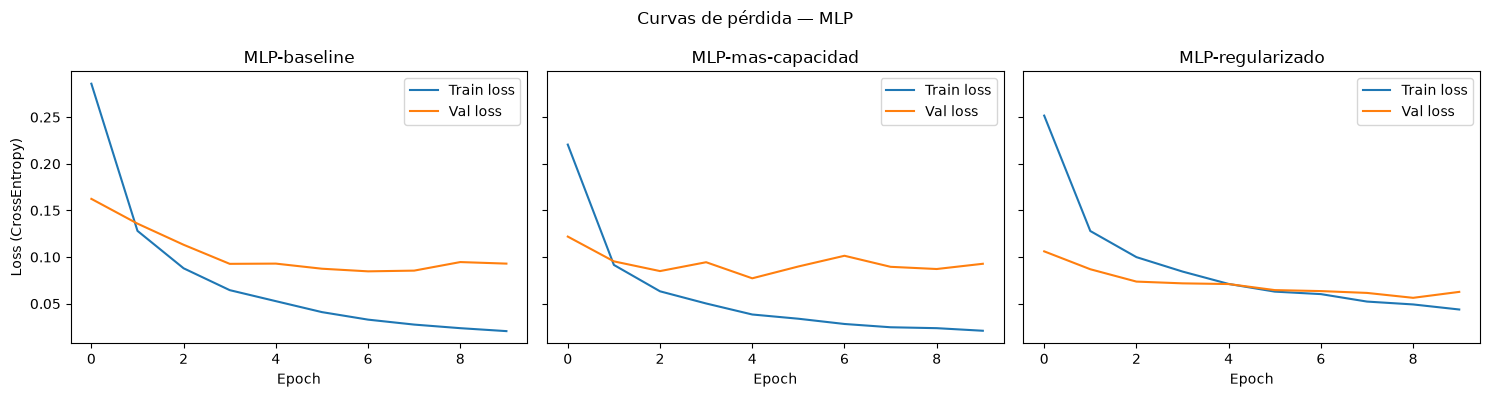

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, result in zip(axes, mlp_results):
    h = result["history"]
    ax.plot(h["train_loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(result["config"]["name"])
    ax.set_xlabel("Epoch")
    ax.legend()
axes[0].set_ylabel("Loss (CrossEntropy)")
plt.suptitle("Curvas de pérdida — MLP")
plt.tight_layout()
plt.show()

# CNN